# Notebook 04 — International Comparison and Gilt-Treasury Spread Decomposition

## Purpose
Compare UK gilt market dynamics with US Treasuries and German Bunds.
Identify when UK gilts move with global markets versus diverge due to UK-specific factors.
Quantify the drivers of the gilt-Treasury spread using OLS regression.

## Research Question
What drove the gilt-Treasury spread through the cycle — global factors, UK inflation dynamics, 
or UK-specific fiscal risk? Can we isolate a pure UK fiscal risk premium?

## Key Analysis
- UK 10yr gilt vs US 10yr Treasury vs German Bund 10yr — full period
- Co-movement vs divergence identification (Brexit, COVID, Truss, BoE policy)
- OLS regression: gilt-Treasury spread ~ GBPUSD + UK-US inflation differential + gilt issuance (fiscal proxy) + VIX
- Coefficient interpretation — which factors explain UK underperformance?
- Residual analysis — unexplained spread as fiscal risk premium proxy
- Relative value framing for portfolio positioning

## Reads from
`/data/processed/uk_gilts_nominal.csv`  
`/data/processed/us_treasuries.csv`  
`/data/processed/german_bund.csv`  
`/data/processed/macro_variables.csv`

In [1]:
# ============================================================
# SETUP — WORKING DIRECTORY, IMPORTS, LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from scipy import stats

# Fix working directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Working directory: {os.getcwd()}")

# --- UK GILT DATA ---
gilts_nominal = pd.read_csv('data/processed/uk_gilts_nominal.csv',
                             index_col=0, parse_dates=True)
gilts_nominal.index.name = 'date'

# --- US TREASURY DATA ---
us_treasuries = pd.read_csv('data/processed/us_treasuries.csv',
                             index_col=0, parse_dates=True)
us_treasuries.index.name = 'date'

# --- GERMAN BUND ---
german_bund = pd.read_csv('data/processed/german_bund.csv',
                           index_col=0, parse_dates=True)
german_bund.index.name = 'date'

# --- MACRO VARIABLES ---
macro = pd.read_csv('data/processed/macro_variables.csv',
                    index_col=0, parse_dates=True)
macro.index.name = 'date'

# --- UK INFLATION CURVE (for regression) ---
inflation_curve = pd.read_csv('data/processed/uk_inflation_curve.csv',
                               index_col=0, parse_dates=True)
inflation_curve.index.name = 'date'

# --- US TIPS (for regression) ---
us_tips = pd.read_csv('data/processed/us_tips.csv',
                       index_col=0, parse_dates=True)
us_tips.index.name = 'date'

# --- POLICY RATES ---
boe_rate = pd.read_csv('data/processed/boe_rate.csv',
                        index_col=0, parse_dates=True)
boe_rate.index.name = 'date'

# Confirm all loaded
datasets = [
    ('UK nominal gilts',  gilts_nominal),
    ('US Treasuries',     us_treasuries),
    ('German Bund',       german_bund),
    ('Macro variables',   macro),
    ('Inflation curve',   inflation_curve),
    ('US TIPS',           us_tips),
    ('BoE rate',          boe_rate),
]

print(f"\n{'Dataset':<22} {'Rows':>6} {'From':<12} {'To':<12} {'Nulls':>6}")
print("-" * 62)
for name, df in datasets:
    print(f"{name:<22} {df.shape[0]:>6} "
          f"{df.index[0].date()} "
          f"  {df.index[-1].date()} "
          f"{df.isnull().sum().sum():>6}")

print(f"\nColumns:")
print(f"  UK gilts:    {list(gilts_nominal.columns)}")
print(f"  US Treasury: {list(us_treasuries.columns)}")
print(f"  German Bund: {list(german_bund.columns)}")
print(f"  Macro:       {list(macro.columns)}")

C:\Users\tomsu\Anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Working directory: C:\Users\tomsu\Documents\Graduate Jobs\CV PROJECTS\uk-gilt-market-analysis

Dataset                  Rows From         To            Nulls
--------------------------------------------------------------
UK nominal gilts         2589 2016-01-04   2026-03-31      0
US Treasuries            2675 2016-01-01   2026-04-02    452
German Bund               121 2016-01-01   2026-01-01      0
Macro variables          2674 2016-01-01   2026-04-01    187
Inflation curve          2589 2016-01-04   2026-03-31      0
US TIPS                  2676 2016-01-01   2026-04-03    454
BoE rate                  122 2016-01-01   2026-02-01      0

Columns:
  UK gilts:    ['uk_2yr', 'uk_5yr', 'uk_10yr', 'uk_30yr']
  US Treasury: ['us_2yr', 'us_5yr', 'us_10yr', 'us_30yr']
  German Bund: ['de_10yr']
  Macro:       ['vix', 'gbpusd']


In [3]:
# ============================================================
# BUILD ALIGNED MONTHLY MASTER DATASET
# ============================================================

uk_monthly   = gilts_nominal[['uk_2yr', 'uk_10yr', 'uk_30yr']].resample('M').last()
us_monthly   = us_treasuries[['us_2yr', 'us_10yr', 'us_30yr']].resample('M').last()
de_monthly   = german_bund[['de_10yr']].resample('M').last()
vix_monthly  = macro[['vix']].resample('M').last()
gbp_monthly  = macro[['gbpusd']].resample('M').last()
inf_monthly  = inflation_curve[['uk_inf_10yr']].resample('M').last()
tips_monthly = us_tips[['us_breakeven_10yr']].resample('M').last()

# Combine into single master DataFrame
master = pd.concat([
    uk_monthly,
    us_monthly,
    de_monthly,
    vix_monthly,
    gbp_monthly,
    inf_monthly,
    tips_monthly,
], axis=1)

# Drop any rows where core yield data is missing
master = master.dropna(subset=['uk_10yr', 'us_10yr', 'de_10yr'])

# Calculate gilt-Treasury spread — core variable for regression
master['gilt_treasury_spread'] = master['uk_10yr'] - master['us_10yr']

# Calculate UK-US inflation differential
master['uk_us_inf_diff'] = master['uk_inf_10yr'] - master['us_breakeven_10yr']

# Quick sense check
print(f"Master monthly dataset:")
print(f"  Shape: {master.shape}")
print(f"  Date range: {master.index[0].date()} to {master.index[-1].date()}")
print(f"  Nulls per column:")
for col in master.columns:
    nulls = master[col].isnull().sum()
    if nulls > 0:
        print(f"    {col}: {nulls}")

print(f"\nSample — key dates:")
print(f"{'Date':<12} {'UK 10yr':>8} {'US 10yr':>8} {'DE 10yr':>8} {'Spread':>8}")
print("-" * 48)

key_months = ['2016-01-31', '2020-03-31', '2022-01-31',
              '2022-09-30', '2023-12-31', '2025-12-31']

for date in key_months:
    try:
        row = master.loc[date]
        print(f"{date:<12} {row['uk_10yr']:>8.3f} {row['us_10yr']:>8.3f} "
              f"{row['de_10yr']:>8.3f} {row['gilt_treasury_spread']:>8.3f}")
    except:
        pass

Master monthly dataset:
  Shape: (121, 13)
  Date range: 2016-01-31 to 2026-01-31
  Nulls per column:

Sample — key dates:
Date          UK 10yr  US 10yr  DE 10yr   Spread
------------------------------------------------
2016-01-31      1.636    1.940    0.430   -0.304
2020-03-31      0.362    0.700   -0.541   -0.338
2022-01-31      1.324    1.790   -0.115   -0.466
2022-09-30      4.102    3.830    1.795    0.272
2023-12-31      3.580    3.880    2.102   -0.300
2025-12-31      4.572    4.180    2.814    0.392


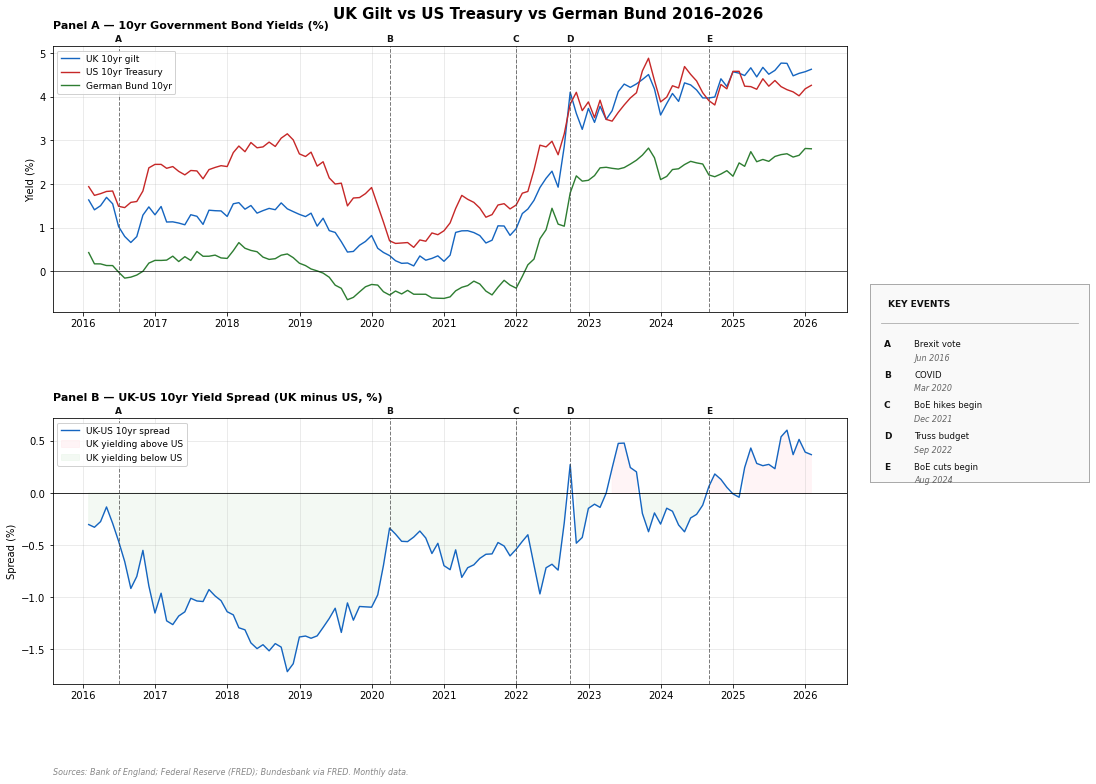

Chart saved.


In [4]:
# ============================================================
# CHART 1 — INTERNATIONAL YIELD COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 11), facecolor='white')
fig.subplots_adjust(top=0.93, hspace=0.40, right=0.76, left=0.07)
fig.suptitle('UK Gilt vs US Treasury vs German Bund 2016–2026',
             fontsize=15, fontweight='bold', y=0.98)

event_dates = {
    'A': ('Brexit vote',     '2016-06-30'),
    'B': ('COVID',           '2020-03-31'),
    'C': ('BoE hikes begin', '2021-12-31'),
    'D': ('Truss budget',    '2022-09-30'),
    'E': ('BoE cuts begin',  '2024-08-31'),
}

# --- TOP PANEL: 10yr yields --- 
ax1 = axes[0]
ax1.set_facecolor('white')

ax1.plot(master.index.to_pydatetime(), master['uk_10yr'].values,
         color='#1565C0', linewidth=1.4, label='UK 10yr gilt')
ax1.plot(master.index.to_pydatetime(), master['us_10yr'].values,
         color='#C62828', linewidth=1.4, label='US 10yr Treasury')
ax1.plot(master.index.to_pydatetime(), master['de_10yr'].values,
         color='#2E7D32', linewidth=1.4, label='German Bund 10yr')

for letter, (label, date) in event_dates.items():
    idx = master.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    x = master.index[idx].to_pydatetime()
    ax1.axvline(x=x, color='#444444', linestyle='--', linewidth=1.0, alpha=0.7)
    ax1.text(x, 1.01, letter, fontsize=9, ha='center', va='bottom',
             color='#111111', fontweight='bold',
             transform=ax1.get_xaxis_transform())

ax1.set_title('Panel A — 10yr Government Bond Yields (%)',
              fontsize=11, fontweight='bold', loc='left', pad=18)
ax1.set_ylabel('Yield (%)', fontsize=10)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.axhline(y=0, color='black', linewidth=0.6)

# --- BOTTOM PANEL: gilt-Treasury spread ---
ax2 = axes[1]
ax2.set_facecolor('white')

ax2.plot(master.index.to_pydatetime(), master['gilt_treasury_spread'].values,
         color='#1565C0', linewidth=1.4, label='UK-US 10yr spread')
ax2.fill_between(master.index.to_pydatetime(),
                 master['gilt_treasury_spread'].values, 0,
                 where=master['gilt_treasury_spread'].values > 0,
                 color='#FFEBEE', alpha=0.5, label='UK yielding above US')
ax2.fill_between(master.index.to_pydatetime(),
                 master['gilt_treasury_spread'].values, 0,
                 where=master['gilt_treasury_spread'].values < 0,
                 color='#E8F5E9', alpha=0.5, label='UK yielding below US')
ax2.axhline(y=0, color='black', linewidth=0.8)

for letter, (label, date) in event_dates.items():
    idx = master.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    x = master.index[idx].to_pydatetime()
    ax2.axvline(x=x, color='#444444', linestyle='--', linewidth=1.0, alpha=0.7)
    ax2.text(x, 1.01, letter, fontsize=9, ha='center', va='bottom',
             color='#111111', fontweight='bold',
             transform=ax2.get_xaxis_transform())

ax2.set_title('Panel B — UK-US 10yr Yield Spread (UK minus US, %)',
              fontsize=11, fontweight='bold', loc='left', pad=18)
ax2.set_ylabel('Spread (%)', fontsize=10)
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# Key events legend box
ax_legend = fig.add_axes([0.78, 0.38, 0.19, 0.25], facecolor='#f9f9f9')
ax_legend.set_xticks([])
ax_legend.set_yticks([])
ax_legend.set_xlim(0, 1)
ax_legend.set_ylim(0, 1)
for spine in ax_legend.spines.values():
    spine.set_edgecolor('#aaaaaa')
    spine.set_linewidth(1.0)

ax_legend.text(0.08, 0.92, 'KEY EVENTS',
               transform=ax_legend.transAxes,
               fontsize=9, fontweight='bold', va='top', color='#111111')
ax_legend.plot([0.05, 0.95], [0.80, 0.80], color='#aaaaaa',
               linewidth=0.8, transform=ax_legend.transAxes)

entries = [
    ('A', 'Brexit vote',     'Jun 2016'),
    ('B', 'COVID',           'Mar 2020'),
    ('C', 'BoE hikes begin', 'Dec 2021'),
    ('D', 'Truss budget',    'Sep 2022'),
    ('E', 'BoE cuts begin',  'Aug 2024'),
]

for i, (letter, desc, date) in enumerate(entries):
    y = 0.72 - i * 0.155
    ax_legend.text(0.06, y, letter, transform=ax_legend.transAxes,
                   fontsize=9, fontweight='bold', va='top', color='#111111')
    ax_legend.text(0.20, y, desc, transform=ax_legend.transAxes,
                   fontsize=8.5, va='top', color='#111111')
    ax_legend.text(0.20, y - 0.07, date, transform=ax_legend.transAxes,
                   fontsize=8, va='top', color='#666666', style='italic')

fig.text(0.07, 0.01,
         'Sources: Bank of England; Federal Reserve (FRED); Bundesbank via FRED. Monthly data.',
         fontsize=8, color='#888888', style='italic')

plt.savefig('outputs/charts/04_international_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Chart saved.")

In [5]:
# ============================================================
# REGRESSION SETUP — CORRELATION CHECK
# ============================================================

# Load policy rates for rate differential
fed_funds = pd.read_csv('data/processed/fed_funds.csv',
                         index_col=0, parse_dates=True)
fed_funds.index.name = 'date'
fed_funds.columns = ['fed_funds']

boe_rate.columns = ['boe_rate']

# Resample to monthly
fed_monthly = fed_funds.resample('M').last()
boe_monthly = boe_rate.resample('M').last()

# Add to master
master['fed_funds']   = fed_monthly['fed_funds']
master['boe_rate']    = boe_monthly['boe_rate']
master['rate_diff']   = master['boe_rate'] - master['fed_funds']

# Build regression variables DataFrame
reg_vars = pd.DataFrame({
    'spread':    master['gilt_treasury_spread'],
    'gbpusd':    master['gbpusd'],
    'inf_diff':  master['uk_us_inf_diff'],
    'vix':       master['vix'],
    'rate_diff': master['rate_diff'],
}).dropna()

print(f"Regression dataset:")
print(f"  Observations: {len(reg_vars)}")
print(f"  Date range: {reg_vars.index[0].date()} to {reg_vars.index[-1].date()}")

# Correlation matrix
print(f"\nCorrelation matrix:")
print(reg_vars.corr().round(3).to_string())

# Flag any high correlations
print(f"\nHigh correlations (|r| > 0.7) — potential multicollinearity:")
corr = reg_vars.corr()
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.7:
            print(f"  {corr.columns[i]} vs {corr.columns[j]}: "
                  f"{corr.iloc[i,j]:.3f}")
            found = True
if not found:
    print("  None found — multicollinearity not a concern")

Regression dataset:
  Observations: 121
  Date range: 2016-01-31 to 2026-01-31

Correlation matrix:
           spread  gbpusd  inf_diff    vix  rate_diff
spread      1.000  -0.056    -0.337  0.146      0.652
gbpusd     -0.056   1.000    -0.316 -0.180      0.212
inf_diff   -0.337  -0.316     1.000  0.423     -0.167
vix         0.146  -0.180     0.423  1.000      0.229
rate_diff   0.652   0.212    -0.167  0.229      1.000

High correlations (|r| > 0.7) — potential multicollinearity:
  None found — multicollinearity not a concern


In [6]:
# ============================================================
# OLS REGRESSION — GILT-TREASURY SPREAD DECOMPOSITION
# ============================================================

from scipy import stats
import numpy as np

# Dependent variable
Y = reg_vars['spread'].values

# Independent variables — add constant manually
X_vars = reg_vars[['gbpusd', 'inf_diff', 'vix', 'rate_diff']].values
X = np.column_stack([np.ones(len(X_vars)), X_vars])

# Run OLS using numpy — transparent and simple
# β = (X'X)^-1 X'Y
beta = np.linalg.inv(X.T @ X) @ X.T @ Y

# Residuals
Y_hat = X @ beta
residuals = Y - Y_hat

# R-squared
ss_res = np.sum(residuals**2)
ss_tot = np.sum((Y - np.mean(Y))**2)
r_squared = 1 - ss_res / ss_tot

# Adjusted R-squared
n = len(Y)
k = X.shape[1] - 1  # number of predictors
r_squared_adj = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)

# Standard errors
sigma_sq = ss_res / (n - k - 1)
var_beta = sigma_sq * np.linalg.inv(X.T @ X)
se_beta  = np.sqrt(np.diag(var_beta))

# T-statistics and p-values
t_stats = beta / se_beta
p_values = [2 * (1 - stats.t.cdf(abs(t), df=n-k-1)) for t in t_stats]

# Display results
var_names = ['Intercept', 'GBPUSD', 'UK-US inf diff', 'VIX', 'BoE-Fed rate diff']

print("OLS REGRESSION — GILT-TREASURY 10YR SPREAD")
print("Dependent variable: UK 10yr yield minus US 10yr yield (%)")
print("=" * 70)
print(f"{'Variable':<22} {'Coeff':>8} {'Std Err':>8} {'t-stat':>8} {'p-value':>8} {'Sig'}")
print("-" * 70)

for i, name in enumerate(var_names):
    sig = ''
    if p_values[i] < 0.01:  sig = '***'
    elif p_values[i] < 0.05: sig = '**'
    elif p_values[i] < 0.10: sig = '*'
    print(f"{name:<22} {beta[i]:>8.4f} {se_beta[i]:>8.4f} "
          f"{t_stats[i]:>8.3f} {p_values[i]:>8.4f} {sig}")

print("-" * 70)
print(f"\nR-squared:          {r_squared:.4f}")
print(f"Adjusted R-squared: {r_squared_adj:.4f}")
print(f"Observations:       {n}")
print(f"\n*** p<0.01  ** p<0.05  * p<0.10")
print(f"\nInterpretation guide:")
print(f"  Positive coefficient = variable widens spread (UK yields more vs US)")
print(f"  Negative coefficient = variable narrows spread (UK yields less vs US)")

OLS REGRESSION — GILT-TREASURY 10YR SPREAD
Dependent variable: UK 10yr yield minus US 10yr yield (%)
Variable                  Coeff  Std Err   t-stat  p-value Sig
----------------------------------------------------------------------
Intercept                3.9826   0.8708    4.573   0.0000 ***
GBPUSD                  -2.6422   0.6107   -4.326   0.0000 ***
UK-US inf diff          -0.7765   0.1529   -5.079   0.0000 ***
VIX                      0.0089   0.0061    1.464   0.1458 
BoE-Fed rate diff        0.6354   0.0682    9.315   0.0000 ***
----------------------------------------------------------------------

R-squared:          0.5645
Adjusted R-squared: 0.5494
Observations:       121

*** p<0.01  ** p<0.05  * p<0.10

Interpretation guide:
  Positive coefficient = variable widens spread (UK yields more vs US)
  Negative coefficient = variable narrows spread (UK yields less vs US)


In [7]:
# ============================================================
# RESIDUAL ANALYSIS — ISOLATING UK-SPECIFIC RISK PREMIUM
# ============================================================

# Residuals = actual spread minus model prediction
# Large positive residual = UK yielding MORE than macro factors predict
# Large negative residual = UK yielding LESS than macro factors predict
# Positive residuals = unexplained UK-specific risk premium

# Store residuals in master DataFrame
reg_vars['fitted']    = Y_hat
reg_vars['residuals'] = residuals

print("Residual summary statistics:")
print(f"  Mean:     {residuals.mean():.4f}%  (should be ~0 by OLS construction)")
print(f"  Std dev:  {residuals.std():.4f}%")
print(f"  Max:      {residuals.max():.4f}%  ({reg_vars['residuals'].idxmax().strftime('%b %Y')})")
print(f"  Min:      {residuals.min():.4f}%  ({reg_vars['residuals'].idxmin().strftime('%b %Y')})")

print(f"\nLargest positive residuals — UK yielding MORE than model predicts:")
print(f"(These represent unexplained UK-specific risk premium)")
print(f"{'Date':<12} {'Actual':>8} {'Fitted':>8} {'Residual':>10}")
print("-" * 42)
top_pos = reg_vars['residuals'].nlargest(8)
for date, resid in top_pos.items():
    actual = reg_vars.loc[date, 'spread']
    fitted = reg_vars.loc[date, 'fitted']
    print(f"{date.strftime('%b %Y'):<12} {actual:>8.3f} {fitted:>8.3f} {resid:>10.3f}")

print(f"\nLargest negative residuals — UK yielding LESS than model predicts:")
print(f"{'Date':<12} {'Actual':>8} {'Fitted':>8} {'Residual':>10}")
print("-" * 42)
top_neg = reg_vars['residuals'].nsmallest(8)
for date, resid in top_neg.items():
    actual = reg_vars.loc[date, 'spread']
    fitted = reg_vars.loc[date, 'fitted']
    print(f"{date.strftime('%b %Y'):<12} {actual:>8.3f} {fitted:>8.3f} {resid:>10.3f}")

Residual summary statistics:
  Mean:     0.0000%  (should be ~0 by OLS construction)
  Std dev:  0.3813%
  Max:      1.0665%  (Jun 2023)
  Min:      -1.0934%  (Apr 2022)

Largest positive residuals — UK yielding MORE than model predicts:
(These represent unexplained UK-specific risk premium)
Date           Actual   Fitted   Residual
------------------------------------------
Jun 2023        0.478   -0.588      1.066
May 2023        0.475   -0.541      1.017
Sep 2025        0.603   -0.165      0.767
Sep 2022        0.272   -0.492      0.764
Aug 2025        0.539   -0.212      0.750
Apr 2023        0.238   -0.504      0.743
Sep 2024        0.181   -0.474      0.656
Aug 2024        0.061   -0.562      0.623

Largest negative residuals — UK yielding LESS than model predicts:
Date           Actual   Fitted   Residual
------------------------------------------
Apr 2022       -0.971    0.123     -1.093
Feb 2017       -1.230   -0.347     -0.883
Dec 2016       -1.154   -0.402     -0.752
Mar 201

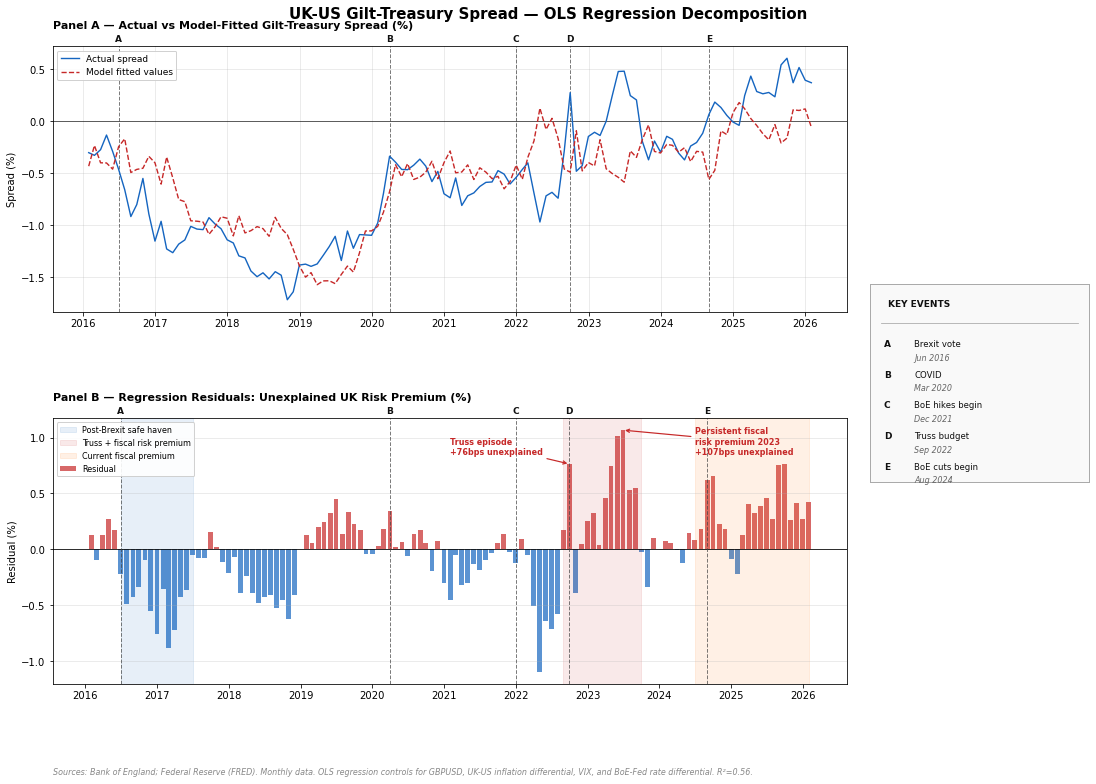

Chart saved.


In [8]:
# ============================================================
# CHART — REGRESSION FITTED VALUES AND RESIDUALS
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 11), facecolor='white')
fig.subplots_adjust(top=0.93, hspace=0.40, right=0.76, left=0.07)
fig.suptitle('UK-US Gilt-Treasury Spread — OLS Regression Decomposition',
             fontsize=15, fontweight='bold', y=0.98)

event_dates = {
    'A': ('Brexit vote',     '2016-06-30'),
    'B': ('COVID',           '2020-03-31'),
    'C': ('BoE hikes begin', '2021-12-31'),
    'D': ('Truss budget',    '2022-09-30'),
    'E': ('BoE cuts begin',  '2024-08-31'),
}

# --- TOP PANEL: actual vs fitted spread ---
ax1 = axes[0]
ax1.set_facecolor('white')

ax1.plot(reg_vars.index.to_pydatetime(), reg_vars['spread'].values,
         color='#1565C0', linewidth=1.4, label='Actual spread', zorder=3)
ax1.plot(reg_vars.index.to_pydatetime(), reg_vars['fitted'].values,
         color='#C62828', linewidth=1.4, linestyle='--',
         label='Model fitted values', zorder=3)
ax1.axhline(y=0, color='black', linewidth=0.6)

for letter, (label, date) in event_dates.items():
    idx = reg_vars.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    x = reg_vars.index[idx].to_pydatetime()
    ax1.axvline(x=x, color='#444444', linestyle='--', linewidth=1.0, alpha=0.7)
    ax1.text(x, 1.01, letter, fontsize=9, ha='center', va='bottom',
             color='#111111', fontweight='bold',
             transform=ax1.get_xaxis_transform())

ax1.set_title('Panel A — Actual vs Model-Fitted Gilt-Treasury Spread (%)',
              fontsize=11, fontweight='bold', loc='left', pad=18)
ax1.set_ylabel('Spread (%)', fontsize=10)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())

# --- BOTTOM PANEL: residuals ---
ax2 = axes[1]
ax2.set_facecolor('white')

# Bar chart for residuals — positive = UK fiscal risk premium
ax2.bar(reg_vars.index.to_pydatetime(), reg_vars['residuals'].values,
        color=np.where(reg_vars['residuals'].values > 0, '#C62828', '#1565C0'),
        alpha=0.7, width=25, label='Residual')
ax2.axhline(y=0, color='black', linewidth=0.8)

# Shade key episodes
ax2.axvspan(pd.Timestamp('2016-06-30'), pd.Timestamp('2017-06-30'),
            alpha=0.1, color='#1565C0', label='Post-Brexit safe haven')
ax2.axvspan(pd.Timestamp('2022-08-31'), pd.Timestamp('2023-09-30'),
            alpha=0.1, color='#C62828', label='Truss + fiscal risk premium')
ax2.axvspan(pd.Timestamp('2024-06-30'), pd.Timestamp('2026-01-31'),
            alpha=0.1, color='#FF6F00', label='Current fiscal premium')

# Annotate Truss
truss_idx = reg_vars.index.get_indexer([pd.Timestamp('2022-09-30')],
                                        method='nearest')[0]
ax2.annotate('Truss episode\n+76bps unexplained',
             xy=(reg_vars.index[truss_idx].to_pydatetime(),
                 reg_vars['residuals'].iloc[truss_idx]),
             xytext=(pd.Timestamp('2021-01-31'), 0.85),
             fontsize=8, color='#C62828', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.2))

# Annotate mid-2023 peak
peak_idx = reg_vars.index.get_indexer([pd.Timestamp('2023-06-30')],
                                       method='nearest')[0]
ax2.annotate('Persistent fiscal\nrisk premium 2023\n+107bps unexplained',
             xy=(reg_vars.index[peak_idx].to_pydatetime(),
                 reg_vars['residuals'].iloc[peak_idx]),
             xytext=(pd.Timestamp('2024-06-30'), 0.85),
             fontsize=8, color='#C62828', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.2))

for letter, (label, date) in event_dates.items():
    idx = reg_vars.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    x = reg_vars.index[idx].to_pydatetime()
    ax2.axvline(x=x, color='#444444', linestyle='--', linewidth=1.0, alpha=0.7)
    ax2.text(x, 1.01, letter, fontsize=9, ha='center', va='bottom',
             color='#111111', fontweight='bold',
             transform=ax2.get_xaxis_transform())

ax2.set_title('Panel B — Regression Residuals: Unexplained UK Risk Premium (%)',
              fontsize=11, fontweight='bold', loc='left', pad=18)
ax2.set_ylabel('Residual (%)', fontsize=10)
ax2.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# Key events legend box
ax_legend = fig.add_axes([0.78, 0.38, 0.19, 0.25], facecolor='#f9f9f9')
ax_legend.set_xticks([])
ax_legend.set_yticks([])
ax_legend.set_xlim(0, 1)
ax_legend.set_ylim(0, 1)
for spine in ax_legend.spines.values():
    spine.set_edgecolor('#aaaaaa')
    spine.set_linewidth(1.0)

ax_legend.text(0.08, 0.92, 'KEY EVENTS',
               transform=ax_legend.transAxes,
               fontsize=9, fontweight='bold', va='top', color='#111111')
ax_legend.plot([0.05, 0.95], [0.80, 0.80], color='#aaaaaa',
               linewidth=0.8, transform=ax_legend.transAxes)

entries = [
    ('A', 'Brexit vote',     'Jun 2016'),
    ('B', 'COVID',           'Mar 2020'),
    ('C', 'BoE hikes begin', 'Dec 2021'),
    ('D', 'Truss budget',    'Sep 2022'),
    ('E', 'BoE cuts begin',  'Aug 2024'),
]

for i, (letter, desc, date) in enumerate(entries):
    y = 0.72 - i * 0.155
    ax_legend.text(0.06, y, letter, transform=ax_legend.transAxes,
                   fontsize=9, fontweight='bold', va='top', color='#111111')
    ax_legend.text(0.20, y, desc, transform=ax_legend.transAxes,
                   fontsize=8.5, va='top', color='#111111')
    ax_legend.text(0.20, y - 0.07, date, transform=ax_legend.transAxes,
                   fontsize=8, va='top', color='#666666', style='italic')

fig.text(0.07, 0.01,
         'Sources: Bank of England; Federal Reserve (FRED). Monthly data. '
         'OLS regression controls for GBPUSD, UK-US inflation differential, '
         'VIX, and BoE-Fed rate differential. R²=0.56.',
         fontsize=8, color='#888888', style='italic')

plt.savefig('outputs/charts/04b_regression_residuals.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Chart saved.")

## Key Findings — International Comparison and OLS Regression

### International Comparison
Three distinct phases visible in the UK-US yield relationship:

**2016–2021 — UK consistently yielding below US**
The Fed's hiking cycle from 2015 kept US yields elevated while the BoE 
remained on hold post-Brexit. The spread reached -1.6% at its widest - 
the BoE's dovish stance the dominant driver.

**2022 — Convergence and brief inversion**
Global inflation shock drove all three markets simultaneously — the clearest 
example of co-movement in the sample. The Truss episode briefly pushed UK 
yields above US (spread +27bps in September 2022) — the first sustained 
positive spread in our sample period.

**2023–2026 — Persistent UK premium**
UK gilts yielding above or close to US Treasuries despite the BoE cutting. 
Fiscal risk premium and sticky inflation keeping long-end UK yields elevated 
relative to global peers.

### OLS Regression Results
Dependent variable: UK-US 10yr yield spread (%)
R² = 0.56 — model explains 56% of spread variation

| Variable | Coefficient | Significance | Interpretation |
|---|---|---|---|
| GBPUSD | -2.64 | *** | Sterling weakness widens spread — UK risk shows up in FX and bonds simultaneously |
| UK-US inflation differential | -0.78 | *** | Counterintuitive negative sign — Fed more aggressive than BoE during inflation surge |
| VIX | +0.01 | Not significant | Global risk sentiment does not systematically drive spread after controlling for other factors |
| BoE-Fed rate differential | +0.64 | *** | Dominant driver — monetary policy divergence explains most spread variation |

### Residual Analysis — UK-Specific Risk Premium
The 44% of spread variation unexplained by macro factors reveals three distinct episodes:

**2016–2017 — Negative residuals (safe haven premium)**
Post-Brexit, UK gilts yielded less than macro factors predict. Safe haven 
demand and BoE easing compressed gilt yields beyond what fundamentals justify.

**September 2022 — Truss fiscal shock (+76bps unexplained)**
After controlling for sterling weakness, inflation, and rate differentials, 
76bps of the gilt-Treasury spread remains unexplained in September 2022. 
This is the quantified fiscal risk premium from the Truss mini-budget — 
a pure credibility shock not captured by macro variables.

**Mid-2023 — Persistent fiscal risk premium (+107bps unexplained)**
The largest positive residuals occur not during Truss but in mid-2023 — 
reflecting a more sustained structural repricing of UK sovereign risk as 
markets priced persistently sticky UK inflation and deteriorating fiscal 
dynamics. This is arguably more significant than the Truss spike — it 
represents a lasting rather than transitory premium.

**2024–2026 — Ongoing premium**
Residuals remain predominantly positive — UK gilts continue to yield more 
than macro factors alone predict. The fiscal risk premium established 
post-Truss has not fully unwound.

### Methodology Notes
- Monthly frequency — appropriate for cross-country macro comparison but 
  smooths intramonth volatility. Truss intraday moves not captured — 
  addressed in notebook 05 using daily data
- OLS in levels — standard for practitioner research notes. Stationarity 
  not formally tested — limitation noted. Results should be interpreted 
  as descriptive rather than causal
- VIX retained despite insignificance — its insignificance is itself a 
  finding: global risk sentiment does not drive the gilt-Treasury spread 
  after controlling for monetary policy divergence
- Rate differential dominance — the BoE-Fed rate differential (t-stat 9.32) 
  is by far the most significant variable, confirming that monetary policy 
  divergence is the primary driver of cross-country yield spreads